In [221]:
import pandas as pd
import numpy as np
import sys,os
sys.path.append("../../")
from utils.utils import *
import matplotlib.pyplot as plt
import seaborn as sns
from src.feature_based_signal_correction.fbsc import plot_signal_drift
from joblib import Parallel,delayed
from tqdm import tqdm 

In [128]:
D = pd.read_csv("../../data/nph_data.csv").drop(columns=['position','mz','rt']).set_index("name").T
M = pd.read_csv("../../data/nph_metadata.csv").set_index("sample_name")
M = M.sort_values(by=['batch','injection_order'])
M['injection_order'] = [x for x in range(1,len(M['injection_order'])+1)]
M['batch'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51])

# Plot QC Signal Against Injection Order

plotting only QC and Biological Samples


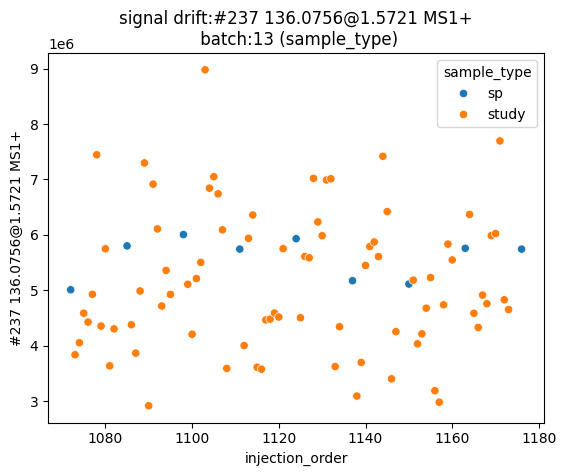

In [150]:
plot_signal_drift(data=D,metadata=M,include_all_samples=False,include_all_batches=False,random_state=1)

# Within Batch Effect Correction: QC-SVRC
* RBF function 
* Regress intensity ~ QC signal intensity 

In [206]:
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler


In [ ]:
#Need to Segregate QC Samples
def svr_function(intensity,injection_order):
    svr = SVR()
    scaler = MinMaxScaler()
    injection_order = scaler.fit_transform(injection_order)
    svr.fit(injection_order,intensity)
    fitted_values = svr.predict(injection_order)
    adjusted = intensity - fitted_values
    return adjusted

In [223]:
def parallel_svr_correction(data, injection_order, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(svr_function)(data[col], injection_order) for col in tqdm(data.columns,desc=f'Correcting signals...')
    )
    corrected = pd.DataFrame(np.array(results).T, 
                             index=data.index, 
                             columns=data.columns)
    return corrected

In [224]:
parallel_svr_correction(D,injection_order=M['injection_order'].to_numpy().reshape(-1,1))

Correcting signals...:   1%|          | 64/12600 [00:17<1:02:19,  3.35it/s]

KeyboardInterrupt: 

# Between Batch Effect Correction : Ratio-based Method 
- scales the intensity of each metabolic feature in each sample, using a factor defined as the ratio between the median intensity in QCs in corresponsing batch and the median intensity in QCs across batches

- group by batch and take the medians across QC samples 
- group by sample type and take the median across QC samples 

- scale each signal by this ratio 

In [ ]:
def ratio_based_correction(data,metadata,QC='sp'):
    D = data.copy()
    M = metadata.copy()
    QC = D.groupby(M['sample_type']).get_group(QC)
    median_across_qc = QC.median()
    median_qc_by_batch = []
    batches = M['batch'].unique()
    batch_group = QC.groupby(M['batch'])
    for batch in batches:
        median_qc_by_batch.append(batch_group.get_group(batch).median())
    scaling_factor = pd.concat(median_qc_by_batch,axis=1)
    scaling_factor.columns = M['batch'].unique()
    scaling_factor = scaling_factor.div(median_across_qc,axis=0)
    corrected_data = []
    batch_samples = D.groupby(M['batch'])
    for batch in batches:
        corrected_data.append(batch_samples.get_group(batch).mul(scaling_factor[batch],axis=1))
    corrected_data = pd.concat(corrected_data)
    corrected_data = corrected_data.loc[D.index]
    return corrected_data    
df = ratio_based_correction(D,M)